# Determinants of Future House Prices
**Ansumana B. Korleh**


*2/2/2026*

## Contents

- [Abstract](#Abstract)
- [Section 1: Introduction](#Section-1:-Introduction)
    - [1.1 Background](#1.1-Background)
    - [1.2 Statement of Problem](#1.2-Statement-of-Problem)
    - [1.3 Objectives](#1.3-Objectives)
- [Section 2: Exploratory Data Analysis and Data Preparation](#Section-2:-Exploratory-Data-Analysis-and-Data-Preparation)
    - [2.1 Loading Relevant Python Libraries and Project Dataset](#Libraries)
    - [2.2 Data Exploration](#2.2-Data-Exploration)
    - [2.3 Data Preparation](#2.3-Data-Preparation)
    - [2.4 Correlation](#2.4-Correlation)
        - [2.4.1 Feature Engineering](#2.4.1-Feature-Engineering)
- [Section 3: Project Methodology and Results](#Section-3:-Project-Methodology-and-Results)
    - [3.1 Linear Regression Model](#3.1-Linear-Regression-Model)
    - [3.2 Result Analysis](#3.2-Result-Analysis)
- [4. Conclusion](#4.-Conclusion)
- [Refrences](#References)

[Back to top](#Determinants-of-Future-House-Prices)

## Abstract

This study develops and evaluates a linear regression model for predicting residential house prices using a set of structural and housing-related characteristics. Two model specifications were estimated: one using the original, untransformed sale price and another based on the logarithmic transformation of sale price. Model performance was assessed using the coefficient of determination (R²). Both specifications achieved an in-sample R² of 0.86, indicating strong explanatory power, with the explanatory variables accounting for 86% of the variation in house prices. Given the comparable performance, the model using the untransformed sale price was selected for interpretability. Visual diagnostics, including histograms and scatterplots, further confirmed good model fit and approximate normality of predictions. Coefficient estimates provided insight into the marginal impact of individual explanatory variables on house prices, while the intercept captured the baseline price level in the absence of predictors. The final model was evaluated on an unseen test dataset after imputing missing values using mean imputation. The out-of-sample R² of 0.77 suggests that the model generalizes well and retains strong predictive performance.

[Back to top](#Determinants-of-Future-House-Prices)

## Section 1: Introduction

### 1.1 Background
Accurate prediction of the prices of residential properties is critical to decision-making in real estate markets, urban planning, mortgage lending, and household investment. Housing prices reflect a complex interaction of structural characteristics, such as size, house style, and year built, location attributes such as streets connected to the property and other neighborhood amenities, and the broader prevailing macroeconomic conditions.

The predictive task is formally defined as a supervised machine learning problem where the predicted variable, otherwise referred to as the dependent variable, is the observed sale price of a house. Predictors are selected after a thorough exploratory data analysis, and they include: OverallQual which rates the overall material and finishing of the house, GrLivArea which is the measure of the living area square feet, GarageArea which is the size of the garage in square feet, GarageCars which is the size of the garage in car capacity, and YearBuilt which is the original construction date of the house, and FullBath which indicates the number of full bathrooms above ground in the house. Exploratory data analysis is conducted on all features to understand distributions, assess and repair missingness, and examine preliminary relationships between sale price and predictor variables.

The core predictive model employed is multiple linear regression, selected for its strong theoretical grounding, computational efficiency, and interpretability. Linear regression provides a clear mapping between explanatory variables and sale prices, allowing estimated coefficients to be interpreted as marginal effects under standard assumptions. 

Model performance is evaluated using the mean squared error, under both training and testing scenarios. Finally, coefficient analysis is done to assess assumptions, interpret results, and draw substantive conclusions.

[Back to top](#Determinants-of-Future-House-Prices)
### 1.2 Statement of Problem
This project addresses the problem of predicting future house prices based on different property characteristics, using a linear regression model. 

[Back to top](#Determinants-of-Future-House-Prices)
### 1.3 Objectives
The primary objective of this project is to generate economically meaningful insights that can be useful to industry actors. Other objectives include: achieving a reliable predictive performance of the predictive model, and identifying the features of a property that influences sale price most.

The problem-solving framework follows a standard data science lifecycle: problem definition (Section 1), data understanding and data preparation (Section 2), modelling, testing, and interpretation (section 3).



## Section 2: Exploratory Data Analysis and Data Preparation
### 2.1 Loading Relevant Python Libraries and Project Dataset
The following dependencies are loded and used for the purpose of this project:
```python
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.impute import SimpleImputer
```

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.impute import SimpleImputer


data = pd.read_csv('houseSmallData.csv')

[Back to top](#Determinants-of-Future-House-Prices)
## 2.2 Data Exploration

In this section of the project, relevant exploratory data analysis (EDA) steps are taken to explore and understand the dataset for the project. These steps helped in prepping the data for feature engineering. For example, through the EDA, it was found that the dependent variable, Sale Price, was not normally distributed, as indicated by the skweness and kurtosis measures. The variable was then transformed by taking the log, which greatly normalized it.

Skew and kurtosis of SalePrice were caculated as follow:
```python
skewness = SalePrice.skew() 
kytosis = SalePrice.kurtosis() 
print(skewness)
print(kytosis)
```
The results show that the variable was highly skewed because, according to Gujarati & Porter (2009), the skweness value of 1.18 indicates that the variable is skwed. 
Similarly for the Kurtosis, the variable was found to be platykurtic (fat or short-tailed) because value its value of 1.55 was less than 3 which indicates that a variable follows a normal distribution (Gujarati & Porter, 2009).

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>],
       [<Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>],
       [<Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>],
       [<Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}

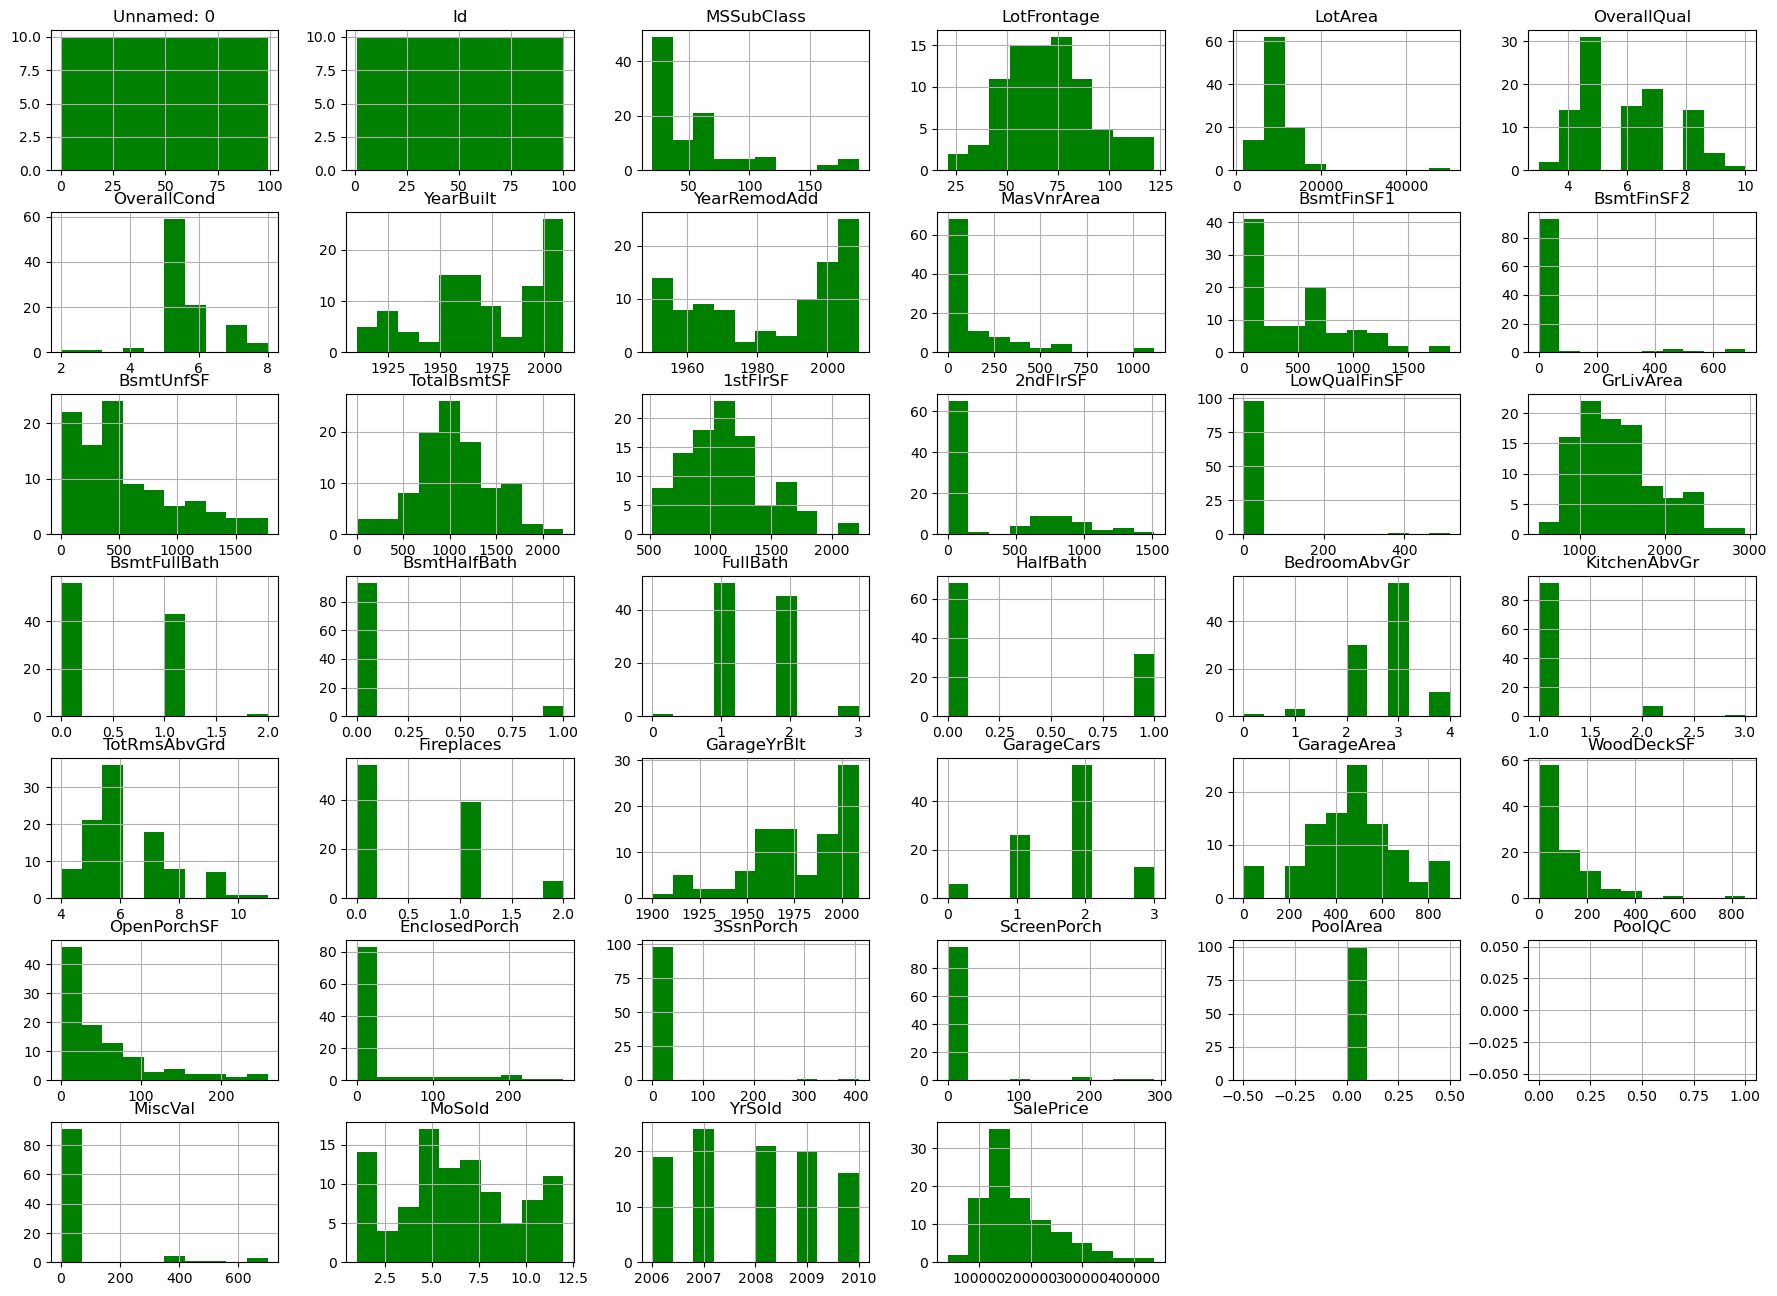

In [ ]:
# Exploratory data analysis. Uncomment the varible to visualize.
head = data.head() # the top rows of the dataset
#head

shape = data.shape # get the number of columns and rows in the dataset
#print(shape)

#data.info() # visualize the metadata of the dataset, including the column names and the count of non-null values

#data.describe() # display the descriptive statistics of the dataset

tail = data.tail() # show the bottom rows of the dataset
#tail

data.hist(figsize = (22, 16), color = 'green') # visualizes the histogram of the entire dataset based on numeric columns


In [7]:
# Define the training set which is based on the entire dataset. Uncomment
# line 6 of data exploratory section above to see the shape of the dataset.
train = data.iloc[0:100,:]
train.shape

(100, 82)

In [10]:
# Let's investigate Sales Price through its descriptive statistics.
# Note that Sales Price is the dependent variable for the project.
SalePrice = train['SalePrice']
SalePrice.describe()

count       100.000000
mean     173820.660000
std       72236.552886
min       40000.000000
25%      129362.500000
50%      153750.000000
75%      207750.000000
max      438780.000000
Name: SalePrice, dtype: float64

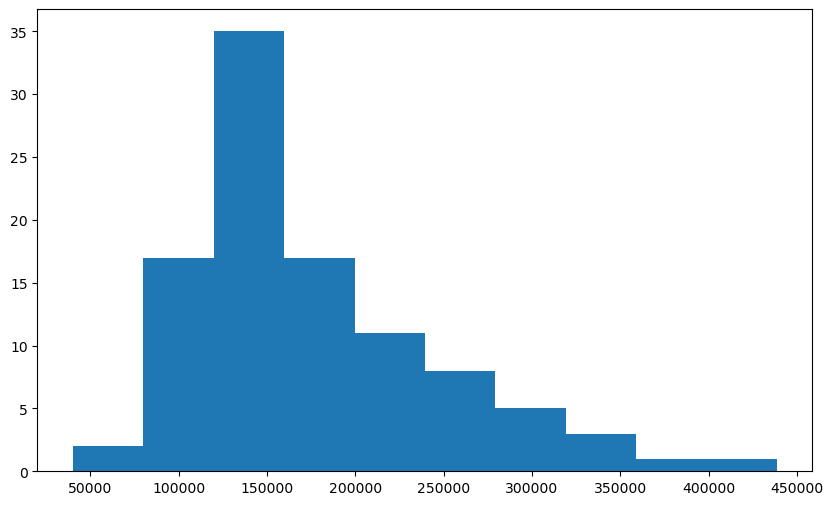

In [489]:
# Visualize the dependent variable, SalePrice
plt.figure(figsize = (10, 6))
plt.hist(SalePrice)
plt.show()

In [490]:
# Obtaining the skew and kurtosis values
skewness = SalePrice.skew() # Highly skewed because value is either less than -1 or greater than +1
kytosis = SalePrice.kurtosis() # platykurtic (fat or short-tailed) because value less than 3. Needs to be 3, in which case SalePrice follows a normal dist.
print(skewness)
print(kytosis)

1.1783462304851948
1.546005686508209


In [218]:
# Let's check to see if we have nulls in our dependent variable and in any of the columns in the independent variables
nulls = SalePrice.isnull().sum()
nulls

np.int64(0)

[Back to top](#Determinants-of-Future-House-Prices)
## 2.3 Data Preparation
Various data preparation and transformation steps are applied to get a clean, more relevant dataset for the model.
After normalizing the dependent variable, it was plotted using histogram to visualize both the transformed and non-transformed variable to see which one was much closer to a normal distribution.

In [219]:
# Let's normalize SalePrice
norm_salePrice = np.log(SalePrice)

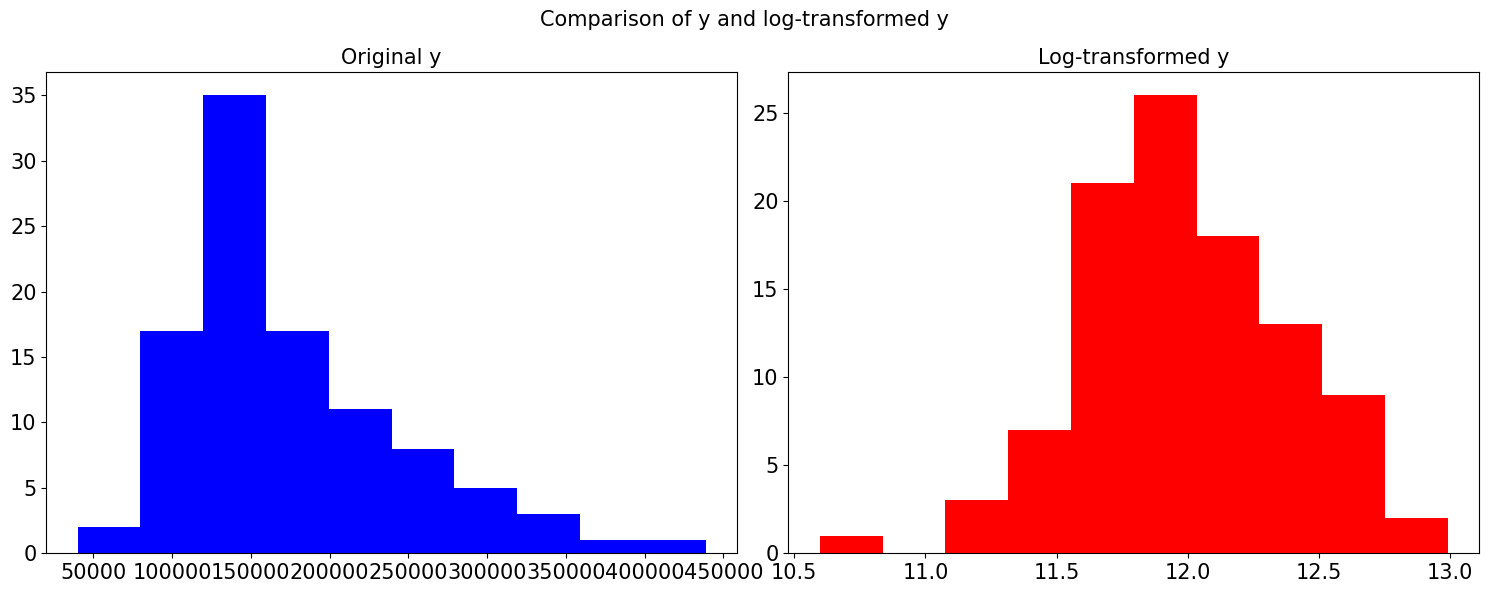

In [220]:
# let's see the visuals for normalized and non-normalized SalePrice side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the original y histogram on the first subplot
ax1.hist(y, color="blue")
ax1.set_title("Original y", fontsize=15)
ax1.tick_params(labelsize=15)

# Plot the transformed y histogram on the second subplot
ax2.hist(norm_salePrice, color="red")
ax2.set_title("Log-transformed y", fontsize=15)
ax2.tick_params(labelsize=15)

# Add a and show visual
fig.suptitle("Comparison of y and log-transformed y", fontsize=15)
plt.tight_layout()
plt.show()

In [221]:
# Let's take skewness and kurtosis of the transformed SalePrice
skewness_norm_salePrice = norm_salePrice.skew()
print(skewness_norm_salePrice)
kur_norm_salePrice = norm_salePrice.kurtosis()
print(kur_norm_salePrice)

-0.09632240207755555
0.7435449520738353


In [11]:
# we can now see from the charts above that SalePrice is much more normally distributed when transformed.so let's make Y the transformed SalePrice
Y_trans = np.log(SalePrice)


[Back to top](#Determinants-of-Future-House-Prices)
## 2.4 Correlation

Correlation analysis was done to analyze the correlation between Sale Price and all other numeric variables in the dataset. The following code was used for this purpose:
```python
numeric_train = train.select_dtypes(include = [np.number])
corr = numeric_train.corrwith(SalePrice)

# Plot
plt.figure(figsize=(10, 6))
corr.sort_values().plot(kind='barh')
plt.xlabel('Correlation with SalePrice')
plt.title('Feature Correlation with log of SalePrice')
plt.show()
```
After that, a similar correlation was drawn between the normalized (log transformed) value of Sale Price and the other numerical variables. The correlation was found to exist with the same variables as found in for the non-transformed variable.

After this correlation analysis for the group of variables, separate correlation analysis was done bewteen Sale Price and various other variables. See sample below, correlation between normalized Sale Price and Overaall Quality of a house:
```python
plt.scatter(train['OverallQual'],y = Y_trans) 
```


C:\Users\getan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\getan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


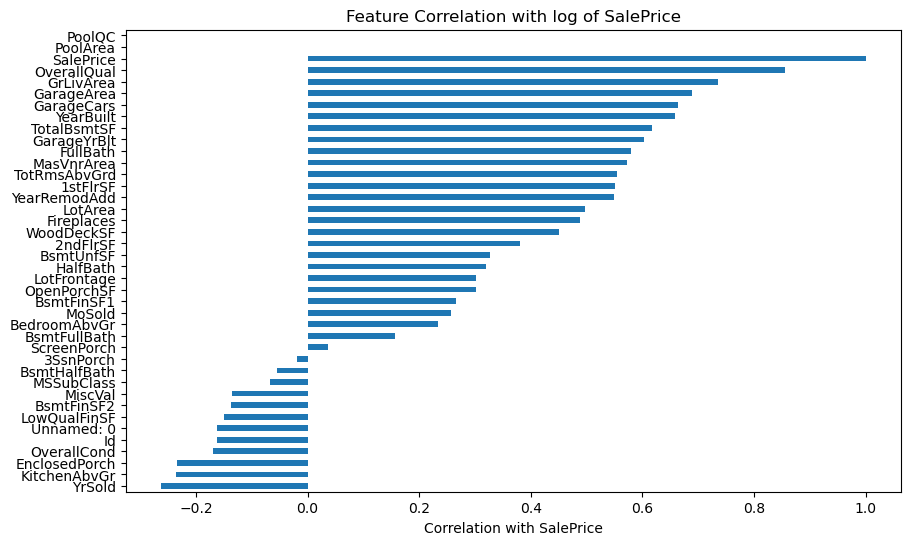

In [364]:
# Let's take a look at correlation between SalePrice (non-transformed Y) and other possible features. 
numeric_train = train.select_dtypes(include = [np.number])
corr = numeric_train.corrwith(SalePrice)

# Plot
plt.figure(figsize=(10, 6))
corr.sort_values().plot(kind='barh')
plt.xlabel('Correlation with SalePrice')
plt.title('Feature Correlation with log of SalePrice')
plt.show()

C:\Users\getan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\getan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


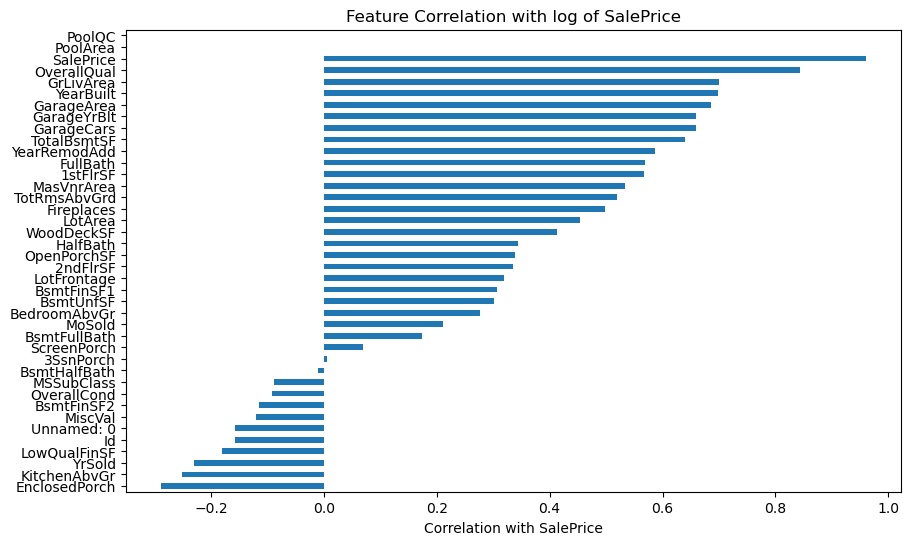

In [366]:
# Let's take a look at correlation between Y_trans (log of SalePrice) and other possible features. 
numeric_train = train.select_dtypes(include = [np.number])
corr = numeric_train.corrwith(Y_trans)

# Plot
plt.figure(figsize=(10, 6))
corr.sort_values().plot(kind='barh')
plt.xlabel('Correlation with SalePrice')
plt.title('Feature Correlation with log of SalePrice')
plt.show()

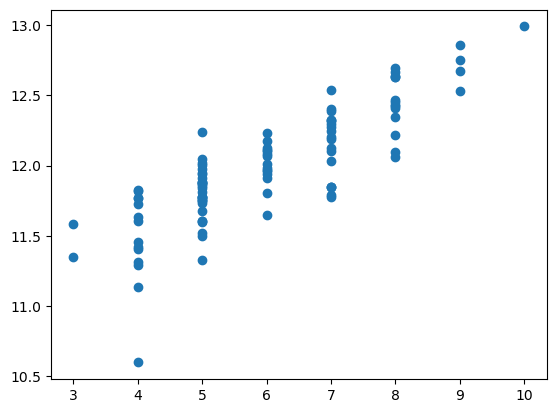

In [ ]:
# Let's plot Y_trans against potential x variables from 
# the correlation chart above

plt.scatter(train['OverallQual'],y = Y_trans) 

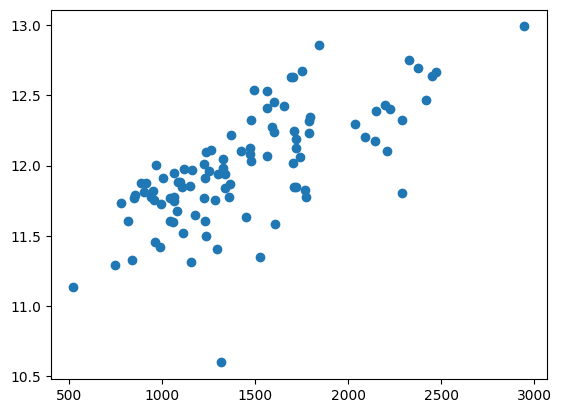

In [12]:
plt.scatter(train["GrLivArea"], y = Y_trans)

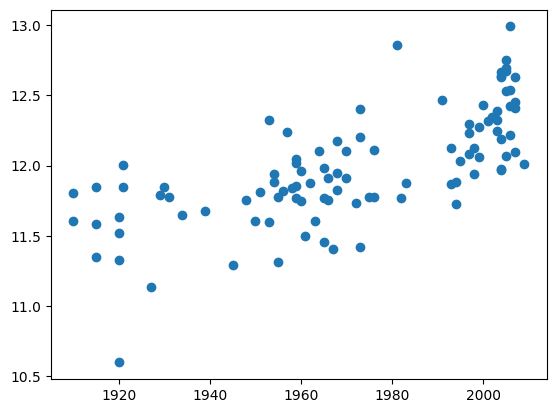

In [14]:
plt.scatter(train["YearBuilt"], y = Y_trans)

[Back to top](#Determinants-of-Future-House-Prices)
## 2.4.1 Feature Engineering
Informed by correlation analysis, features of the model were selected based on the level of correlation with Sale Price. 
First step in this process was the definition of a new training set (new_train) based on only numeric columns.
This produced a 100 by 39 dataframe, as shown by the code ```python new_train.shape ```.
The top 13 features of the most correlation with Sale Price were then drawn, using the following code:
```python
corr = new_train.corr()
features = corr['SalePrice'].sort_values(ascending = False)[0:13].index
features
```

An annotated heatmap was then drawn to show the correlation of the features with Sale Price, using seaboarn visualization as follow:
```python
features_corr = new_train[features]
sns.heatmap(features_corr.corr(), annot = True)
```


In [367]:
# Let's now look at columns with null values, which we should not be including in our analysis
nulls_train = train.isnull().sum().sort_values(ascending = False)[0:20]
nulls_train

# Let's define a new train dataset by selecting columns of numeric datatypes from our train dataset.
new_train = train.select_dtypes(include = [np.number]).interpolate().dropna(axis=1)
sum(new_train.isnull().sum() !=0)
new_train.shape

(100, 39)

In [493]:
new_train.head()

,Unnamed: 0,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0,1,60,65.0,8450,7,5,2003,2003,196.0,...,0,61,0,0,0,0,0,2,2008,208500
1,1,2,20,80.0,9600,6,8,1976,1976,0.0,...,298,0,0,0,0,0,0,5,2007,181500
2,2,3,60,68.0,11250,7,5,2001,2002,162.0,...,0,42,0,0,0,0,0,9,2008,223500
3,3,4,70,60.0,9550,7,5,1915,1970,0.0,...,0,35,272,0,0,0,0,2,2006,140000
4,4,5,60,84.0,14260,8,5,2000,2000,350.0,...,192,84,0,0,0,0,0,12,2008,250000


In [492]:
# Let's select independent variables, X, based on the correlation with Sale Price. 
corr = new_train.corr()
features = corr['SalePrice'].sort_values(ascending = False)[0:13].index
features


Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageArea', 'GarageCars',
       'YearBuilt', 'TotalBsmtSF', 'GarageYrBlt', 'FullBath', 'MasVnrArea',
       'TotRmsAbvGrd', '1stFlrSF', 'YearRemodAdd'],
      dtype='object')

<Axes: >

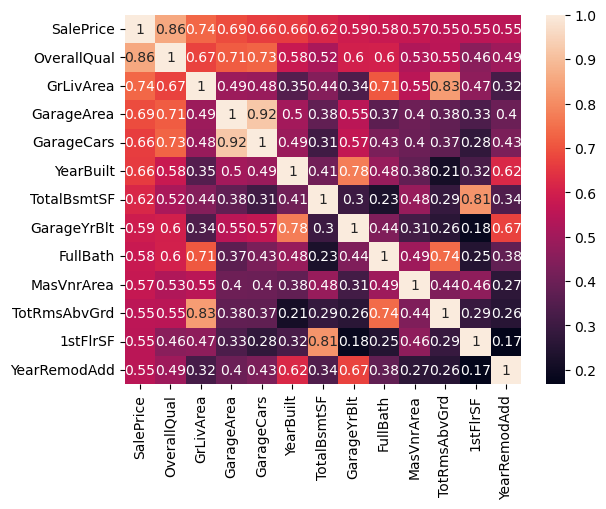

In [424]:
# Let's draw a heatmap to visualize the correlation between SalePrice and our selected features
features_corr = new_train[features]
sns.heatmap(features_corr.corr(), annot = True)

[Back to top](#Determinants-of-Future-House-Prices)
## Section 3: Project Methodology and Results
This section descripes the analytics framework employed in this project, with a brief description of the theoretical and empirical underpinings of the methodology.


In [425]:
X = new_train[features]
Y = X['SalePrice']
X = X.drop(['SalePrice'], axis = 1)
X.head()

,OverallQual,GrLivArea,GarageArea,GarageCars,YearBuilt,TotalBsmtSF,GarageYrBlt,FullBath,MasVnrArea,TotRmsAbvGrd,1stFlrSF,YearRemodAdd
0,7,1710,548,2,2003,856,2003.0,2,196.0,8,856,2003
1,6,1262,460,2,1976,1262,1976.0,2,0.0,6,1262,1976
2,7,1786,608,2,2001,920,2001.0,2,162.0,6,920,2002
3,7,1717,642,3,1915,756,1998.0,1,0.0,7,961,1970
4,8,2198,836,3,2000,1145,2000.0,2,350.0,9,1145,2000


In [473]:
# Results of model on non-transformed dependent variable
lr = linear_model.LinearRegression()
model1 = lr.fit(X,Y)
predictions = model1.predict(X)
print(f'R^2 is: {model1.score(X,Y):.2f}')


R^2 is: 0.86


In [482]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {model1.intercept_:.2f}")
coefficients

Intercept: -1432490.44


,Feature,Coefficient
0,OverallQual,18729.235517
4,YearBuilt,545.351795
11,YearRemodAdd,323.946562
2,GarageArea,51.250308
1,GrLivArea,50.128667
5,TotalBsmtSF,18.558690
8,MasVnrArea,11.469461
10,1stFlrSF,6.410651
6,GarageYrBlt,-160.537454
9,TotRmsAbvGrd,-2111.672885


In [466]:
# Result of model on transformed dependent variable

lr = linear_model.LinearRegression()
model2 = lr.fit(X,Y_trans)
predictions = model2.predict(X)
print(f'R^2 is: {model2.score(X,Y_trans):.2f}')

R^2 is: 0.86


<Axes: xlabel='SalePrice', ylabel='Count'>

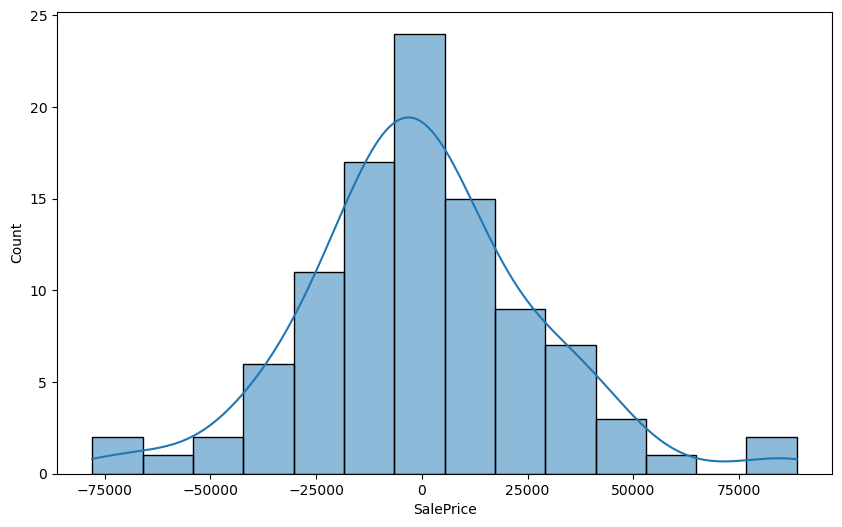

In [456]:
plt.figure(figsize = (10,6))
sns.histplot(data = Y - predictions, kde = True)

Text(0.5, 1.0, 'Scatterplot of Actual & Predicted House Price')

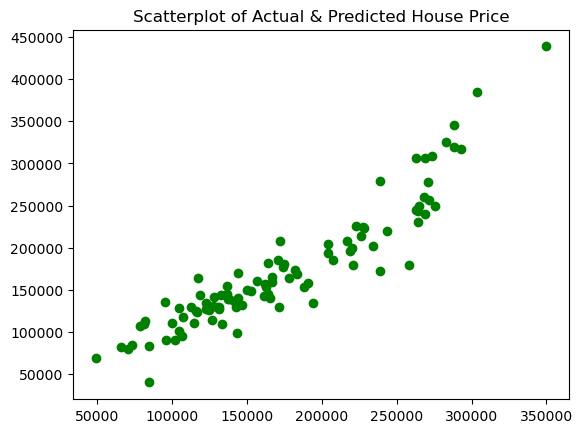

In [457]:
plt.scatter(predictions, Y, color = 'g')
plt.title('Scatterplot of Actual & Predicted House Price')

[Back to top](#Determinants-of-Future-House-Prices)
### 3.1 Linear Regression Model
The mathematical expression for the linear regression model used in this model is:
$$
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n + \epsilon
$$

where $\beta$ is the coefficient of variation, `X` is the explanatory variable, and `Y` is the dependent variable.

Based on the available data, as defined in the nes_train dataset, Y was estimated using the sklearn LinearRegression function, defined and fitted using the following algorithm:
```python
lr = linear_model.LinearRegression()
model1 = lr.fit(X,Y)
predictions = model1.predict(X)
```
[Back to top](#Determinants-of-Future-House-Prices)
## 3.2 Result Analysis

**Training Model**

The first aspect of the result analysis focuses on the model's performance, measured by it's R-squared ($R^2$) score or degree of fitness. As a rule of thumb, $R^2$ value ranging from 0.7 to 0.9 indicates a good model performance. Two models were specified: one (model1) based on the actual, untransformed value of Sales Price and the other (model2) based on the log transformed value of Sale Price.

Given the $R^2$ values of 0.86 for both models, model1 was decided on as the final model. The $R^2$ value of 0.86 therefore indicate that the training model performed well in predicting the dependent variable. Specifically, it means that the explanatory variables explain 86% of the variations in Sale Price, the dependent variable. This performance of the model can be seen visually from the histogram and scatterplot visuals which both show a much a much normal distribution and fitness of theprediction.

The coefficient dataframe, as seen below, shows the specific impact of each of the explanatory variables on the Sales Price of a house. Similarly, the intercept shows what Sale Price would be if there was no explanatory variable, that is if there were no factors to consider in the sale of a house.

**Testing Model**

The model was then tested on a separate, new dataset that it had not seen before. The test dataset had a missing values in one of the independent variables. This had to be taken care of through sklearn impute function.

The test set was then passed onto the model. The model's degree of fitness ( $R^2$) value of 0.77 indicate a good performance of the model.

In [458]:
# Now let's test our model on data that it has never seen
test = pd.read_csv('jtest.csv')
print(test.shape)
test.head()

(100, 82)


,Unnamed: 0,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,100,101,20,RL,NaN,10603,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,205000
1,101,102,60,RL,77.0,9206,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,178000
2,102,103,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118964
3,103,104,20,RL,94.0,10402,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,198900
4,104,105,50,RM,NaN,7758,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,169500


In [459]:
X_test = test[features]
Y_test = X_test['SalePrice']
X_test = X_test.drop(['SalePrice'], axis =1)
X_test.head()

,OverallQual,GrLivArea,GarageArea,GarageCars,YearBuilt,TotalBsmtSF,GarageYrBlt,FullBath,MasVnrArea,TotRmsAbvGrd,1stFlrSF,YearRemodAdd
0,6,1610,480,2,1977,1610,1977.0,2,28.0,6,1610,2001
1,6,1732,476,2,1985,741,1985.0,2,336.0,7,977,1985
2,5,1535,410,2,1979,0,1979.0,2,0.0,8,1535,1979
3,7,1226,740,3,2009,1226,2009.0,2,0.0,6,1226,2009
4,7,1818,240,1,1931,1040,1951.0,1,600.0,7,1226,1950


In [460]:
# Let's check to see if our test set has null values present
X_test.isna().sum().sort_values(ascending = False)

GarageYrBlt     9
OverallQual     0
GarageArea      0
GrLivArea       0
GarageCars      0
YearBuilt       0
TotalBsmtSF     0
FullBath        0
MasVnrArea      0
TotRmsAbvGrd    0
1stFlrSF        0
YearRemodAdd    0
dtype: int64

In [497]:
# Taking care of the null values by imputing the mean of the column for the null values
# Create an imputer to replace NaN values with the mean of each column
X_test['GarageYrBlt'] = imputer.fit_transform(
    X_test[['GarageYrBlt']]
)
X_test.isnull().sum().sort_values(ascending = False)


OverallQual     0
GrLivArea       0
GarageArea      0
GarageCars      0
YearBuilt       0
TotalBsmtSF     0
GarageYrBlt     0
FullBath        0
MasVnrArea      0
TotRmsAbvGrd    0
1stFlrSF        0
YearRemodAdd    0
dtype: int64

In [469]:
# Making predictions based on test data (X_test)

predictions = model1.predict(X_test)
print(f'R^2 is: {model1.score(X_test,Y_test):.2f}')

R^2 is: 0.77


[Back to top](#Determinants-of-Future-House-Prices)
## 4. Conclusion

Housing prices reflect a complex combination of various factors, including structural, location, and macroeconomic. While it is very important to industry actors and policy makers to have an idea of what future sale prices might be like, developing accurate predictive models requires a careful scientific process to avoid misleading results. This project aimed at adopting a scientific, step by step empirical process to predict house sales. The steps included selecting a comprehensive housing dataset, cleaning and analyzing the data, and specifying the relevant predictive model, among others. The model used to predict house prices was a multiple linear regression model which performed well on both the training and test datasets, with $R^2$ values of 86% and 77% respectively.

Generally, the project execution went well. However, for future efforts, it would be a good thing to include other data points such as geographical data like state, region, or country and economic data such as inflation and average income, in order to account for a much wider context.

[Back to top](#Determinants-of-Future-House-Prices)
## References
- Gujarati, Damodar N. “Basic Econometrics.”, Fifth Edition (2009), *McGraw-Hill Inc.*, New York.
- Bobbit, Zach. “What is a Good R-squared Value?” Statology, 2020. www.statology.org/good-r-squared-value/